# 04 Transformer and Attention

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Understand **self-attention**: each position can attend to all positions
- Build a model around a **MultiHeadAttention** layer (Keras) and train it on **real movie reviews** (the IMDB dataset)
- **Read the attention weights over an actual sentence** and judge honestly how interpretable they are
- See why we mask padding, and why attention is not automatically an explanation

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 4, lesson 01 "Bridge: Attention and Transformers — Just Enough to Use Them" — attention explained as a weighted average; here you build the layer.

**Used later in:** Course 10 (AIAT 124) — Unit 2, lesson 01 "Text Generation with Autoregressive (GPT-style) Models".

---

## 🌍 Real life

**Where is this used?** Transformers and attention are used in **BERT**, **GPT**, **machine translation**, and **vision** (ViT) and are the backbone of modern NLP and many vision models.

**In this notebook we use** **self-attention** (MultiHeadAttention) so each token can **look at all other tokens** in one step. We run it on **real IMDB reviews** rather than random integers: attention weights over random tokens are noise, and you cannot tell whether a layer learned anything from noise. Over real English you can — you read the words it attends to.

**📌 Covers slide(s):** **03** — Attention Mechanism. *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **Self-attention:** For each position, we compute **query**, **key**, **value**. Output at position i = weighted sum of values, where weights = softmax(query_i · keys). So each position can attend to **all** positions.
- **Multi-head attention:** Run several attention "heads" in parallel and concatenate; each head can learn different types of relationships.
- **Transformer:** Stack of self-attention + feedforward layers, with residual connections and layer norm. No recurrence; order is encoded via **positional encodings**.
- **Padding must be masked.** Real sentences have different lengths, so short ones are padded with zeros. Without an `attention_mask`, softmax spends probability mass on those padding slots and every attention row you inspect is diluted. We pass the mask explicitly and check that each row sums to 1 over the real tokens only.
- **We use attention** instead of RNN when we need **long-range dependencies** and parallel computation; transformers scale well and have become standard in NLP and vision.

### Key math (required)

- **Query, Key, Value:** For each position we have \(Q = X W_Q\), \(K = X W_K\), \(V = X W_V\) (learned projections).
- **Scaled dot-product attention:** \(\text{Attention}(Q,K,V) = \text{softmax}\big(\frac{QK^T}{\sqrt{d_k}}\big)V\). The \(\sqrt{d_k}\) scaling avoids tiny gradients when \(d_k\) is large.
- **Output at position \(i\):** weighted sum of values \(V\), where weights are \(\text{softmax}(q_i^T K / \sqrt{d_k})\) — so position \(i\) can attend to all positions. For full derivation (multi-head, layer norm), see the lecture slides or Vaswani et al., "Attention Is All You Need."


## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, PyTorch, scikit-learn. **Real data, already cached locally** (no download): the **IMDB movie-review** dataset that ships with Keras — 50,000 real reviews written by real people, already tokenised to integer word ids and labelled positive/negative.

**Dataset:** IMDB. We keep the 10,000 most frequent words, truncate/pad each review to 200 tokens, and sample 6,000 training and 4,000 test reviews so the notebook runs in well under a minute. The classes are almost exactly balanced, so the majority-class baseline is ~50% — we print it rather than assume it.

**Outputs:** Model summary, held-out accuracy against the majority baseline, and — the point of the notebook — the **attention weights over one real review, decoded back into English words**, so you can see for yourself which words the layer looks at and how strong that preference actually is.

---


## Step 1: Imports and load the real IMDB reviews

In [1]:
# WHAT: import TensorFlow/Keras (guarded) and load the REAL IMDB movie-review dataset.
# WHY: MultiHeadAttention ships with Keras - no external transformer library is needed - and
#      IMDB is cached locally, so this cell needs no network access.
import numpy as np

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

print("TensorFlow:", "yes" if HAS_TF else "no")

if HAS_TF:
    keras.utils.set_random_seed(42)          # reproducible weight init and shuffling
    VOCAB_SIZE = 10_000                      # keep the 10k most frequent words
    MAX_LEN = 200                            # truncate/pad every review to 200 tokens

    # Real reviews, already tokenised to integer word ids by Keras.
    (train_raw, y_train_all), (test_raw, y_test_all) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

    # Pad at the END so the real words sit at the front - that makes the attention
    # matrix easy to slice later (positions 0..len-1 are the actual review).
    def pad(seqs):
        return keras.preprocessing.sequence.pad_sequences(
            seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    rng = np.random.default_rng(42)
    tr_idx = rng.permutation(len(train_raw))[:6000]   # subsample: keeps the notebook under a minute
    te_idx = rng.permutation(len(test_raw))[:4000]
    x_train, y_train = pad(train_raw[tr_idx]), y_train_all[tr_idx]
    x_test, y_test = pad(test_raw[te_idx]), y_test_all[te_idx]

    review_lengths = np.array([len(r) for r in train_raw])
    print(f"IMDB: {len(train_raw):,} train / {len(test_raw):,} test reviews written by real users")
    print(f"Review length: median {np.median(review_lengths):.0f} tokens, "
          f"90th percentile {np.percentile(review_lengths, 90):.0f} - so 200 tokens truncates "
          f"{(review_lengths > MAX_LEN).mean() * 100:.0f}% of them")
    print(f"Working subset: {x_train.shape} train, {x_test.shape} test")
    print(f"Positive share: train {y_train.mean():.3f}, test {y_test.mean():.3f} "
          f"-> majority-class baseline is {max(y_test.mean(), 1 - y_test.mean()) * 100:.1f}%")


TensorFlow: yes


IMDB: 25,000 train / 25,000 test reviews written by real users
Review length: median 178 tokens, 90th percentile 467 - so 200 tokens truncates 43% of them
Working subset: (6000, 200) train, (4000, 200) test
Positive share: train 0.495, test 0.506 -> majority-class baseline is 50.6%


## Step 2: Build a classifier around MultiHeadAttention (attention looks at all positions at once, with padding masked out)

In [2]:
# WHAT: wire an Embedding + positional encoding + MultiHeadAttention into a tiny classifier,
#       and ask the layer to hand back its attention scores.
# WHY: self-attention (query = key = value = the same sequence) is the core block of every
#      Transformer; returning the scores is what lets us inspect it on a real sentence later.
if HAS_TF:
    d_model = 32
    num_heads = 2

    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    token_emb = layers.Embedding(VOCAB_SIZE, d_model)(inp)
    # Learned positional encoding: attention itself is order-blind, so position must be added in.
    pos_emb = layers.Embedding(MAX_LEN, d_model)(tf.range(MAX_LEN))
    x = token_emb + pos_emb

    # Padding mask: shape (batch, 1, MAX_LEN). True = a real token a query may attend to.
    # Broadcasting over the query axis applies the same key-mask to every row of the matrix.
    pad_mask = layers.Lambda(
        lambda t: tf.cast(tf.not_equal(t, 0), "bool")[:, tf.newaxis, :],
        output_shape=(1, MAX_LEN), name="padding_mask")(inp)

    mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
    # Passing the same tensor as query and value makes this SELF-attention.
    attn_out, attn_scores = mha(x, x, attention_mask=pad_mask, return_attention_scores=True)

    pooled = layers.GlobalAveragePooling1D()(attn_out)
    out = layers.Dense(1, activation="sigmoid")(pooled)

    # Two views of the SAME weights: one for training, one that also emits the attention matrix.
    classifier = keras.Model(inp, out)
    inspector = keras.Model(inp, [out, attn_scores])

    classifier.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    classifier.summary()
    print(f"\nAttention scores tensor: (batch, {num_heads} heads, {MAX_LEN} queries, {MAX_LEN} keys)")
    print("Each row is a softmax over the keys, so it sums to 1 - we verify that below.")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 32)   │    320,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 200, 32)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, 1, 200)    │          0 │ input_layer[0][0] │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 200, 32), │      4,224 │ add[0][0],        │
│ (MultiHeadAttentio… │ (None, 2, 200,    │            │ add[0][0],        │
│                     │ 200)]             │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         33 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 324,257 (1.24 MB)

 Trainable params: 324,257 (1.24 MB)

 Non-trainable params: 0 (0.00 B)


Attention scores tensor: (batch, 2 heads, 200 queries, 200 keys)
Each row is a softmax over the keys, so it sums to 1 - we verify that below.


## Step 3: Train on real reviews, then read the attention weights over an actual review

Epoch 1/3


85/85 - 3s - 31ms/step - accuracy: 0.6694 - loss: 0.6369 - val_accuracy: 0.7467 - val_loss: 0.5072


Epoch 2/3


85/85 - 2s - 26ms/step - accuracy: 0.8600 - loss: 0.3351 - val_accuracy: 0.8483 - val_loss: 0.3814


Epoch 3/3


85/85 - 2s - 25ms/step - accuracy: 0.9339 - loss: 0.1871 - val_accuracy: 0.8617 - val_loss: 0.3987



Held-out accuracy: 83.4%   majority-class baseline: 50.6%
Edge over the baseline: +32.8 points on 4,000 real reviews.

Review (first in the test split, 68 tokens):
  <start> please give this one a miss br br <unk> <unk> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <unk> so all you madison fans give this a miss

True label: negative   model P(positive) = 0.012 -> correct
Sanity check - one attention row sums to 1.000 over the real tokens (the padding mask is working).

Uniform attention would give every token 0.0147.
Most-attended tokens (share of attention received, and ratio to uniform):
   terrible       0.0156  (1.06x uniform)
   flat           0.0151  (1.03x uniform)
   flat           0.0151  (1.02x uniform)
   flat           0.0150  (1.02x uniform)
   please         0.0149  (1.02x

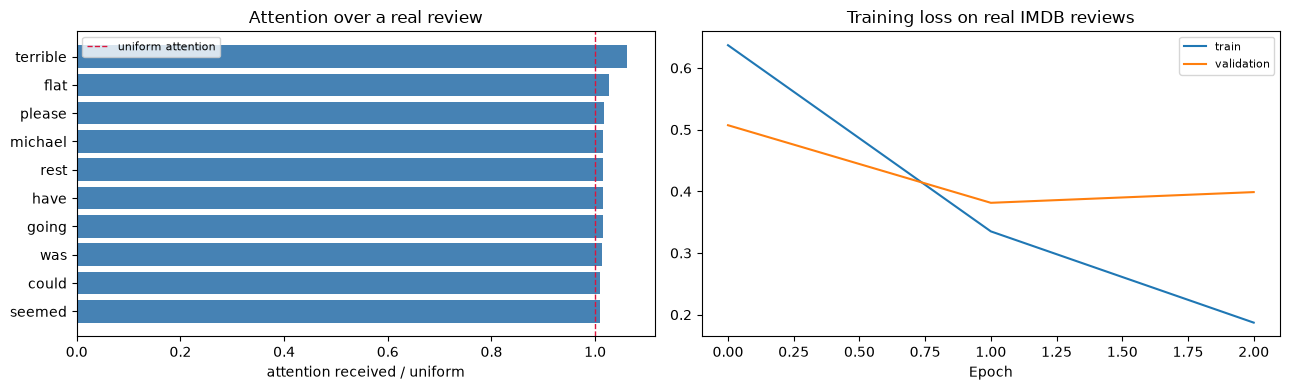

In [3]:
# WHAT: train for 3 epochs on real reviews, score against the majority baseline, then decode
#       the attention weights for one real review back into English words.
# WHY: on random tokens 'accuracy' and 'attention' are both meaningless. On real text you can
#      check both: does the model beat the baseline, and does it look at words a human would?
if HAS_TF:
    import matplotlib.pyplot as plt

    history = classifier.fit(x_train, y_train, epochs=3, batch_size=64,
                            validation_split=0.1, verbose=2)
    test_loss, test_acc = classifier.evaluate(x_test, y_test, verbose=0)
    majority = max(y_test.mean(), 1 - y_test.mean())
    print(f"\nHeld-out accuracy: {test_acc * 100:.1f}%   majority-class baseline: {majority * 100:.1f}%")
    print(f"Edge over the baseline: {(test_acc - majority) * 100:+.1f} points on {len(y_test):,} real reviews.")

    # ── Decode integer ids back to words ────────────────────────────────────
    # Keras offsets the word index by 3 to make room for <pad>, <start> and <unk>.
    word_index = keras.datasets.imdb.get_word_index()
    id_to_word = {v + 3: k for k, v in word_index.items()}
    id_to_word.update({0: "<pad>", 1: "<start>", 2: "<unk>", 3: "<unused>"})

    # No cherry-picking: we simply take the FIRST review in the IMDB test split.
    review_ids = test_raw[0][:MAX_LEN]
    n_tokens = len(review_ids)
    words = [id_to_word.get(i, "?") for i in review_ids]
    prob, scores = inspector.predict(pad([test_raw[0]]), verbose=0)

    print(f"\nReview (first in the test split, {n_tokens} tokens):")
    print("  " + " ".join(words))
    print(f"\nTrue label: {'positive' if y_test_all[0] == 1 else 'negative'}   "
          f"model P(positive) = {prob[0, 0]:.3f} -> "
          f"{'correct' if (prob[0, 0] > 0.5) == (y_test_all[0] == 1) else 'WRONG'}")

    # attention_scores[0] is (heads, queries, keys). Average over heads, then over query rows,
    # to get "how much attention each token RECEIVES from the rest of the sentence".
    A = np.array(scores)[0][:, :n_tokens, :n_tokens]
    print(f"Sanity check - one attention row sums to {A[0, 0].sum():.3f} over the real tokens "
          f"(the padding mask is working).")
    received = A.mean(axis=0).mean(axis=0)
    uniform = 1.0 / n_tokens

    order = np.argsort(-received)[:12]
    print(f"\nUniform attention would give every token {uniform:.4f}.")
    print("Most-attended tokens (share of attention received, and ratio to uniform):")
    for i in order:
        print(f"   {words[i]:<14s} {received[i]:.4f}  ({received[i] / uniform:.2f}x uniform)")

    spread = received.max() / received.min()
    print(f"\nHONEST READING: the ranking is sensible - sentiment-bearing words come out on top -")
    print(f"but the SPREAD is small: most attended / least attended = {spread:.2f}x, and the top")
    print(f"token gets only {received[order[0]] / uniform:.2f}x the uniform share. One attention layer trained")
    print("for 3 epochs on 6,000 reviews mostly averages the sentence; it does not produce the")
    print("crisp 'the model looked HERE' picture that attention heatmaps are often sold as.")
    print("Treat attention as a weak diagnostic, not as an explanation (Jain & Wallace, 2019).")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    top = order[::-1]
    axes[0].barh([words[i] for i in top], [received[i] / uniform for i in top], color="steelblue")
    axes[0].axvline(1.0, color="crimson", ls="--", lw=1, label="uniform attention")
    axes[0].set_xlabel("attention received / uniform")
    axes[0].set_title("Attention over a real review")
    axes[0].legend(fontsize=8)
    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="validation")
    axes[1].set_title("Training loss on real IMDB reviews")
    axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()


## 🌍 Real-World Worked Example — A Mini-Transformer vs. a Bag of Words

**Industry context:**
- **Tweet sentiment is a published benchmark.** TweetEval (Barbieri et al., *Findings of EMNLP 2020*, [arXiv:2010.12421](https://arxiv.org/abs/2010.12421)) bundles seven Twitter classification tasks — sentiment among them — and shows that continuing to train a general pre-trained model on Twitter text beats training from scratch.
- **Amazon publishes the review data and the BERT baseline.** The Multilingual Amazon Reviews Corpus (Keung, Lu, Szarvas & Smith, Amazon, *EMNLP 2020*) holds 200,000 training reviews per language in six languages collected 2015-2019, with reported baselines that fine-tune multilingual BERT.
- **Ticket triage ships as a product.** Zendesk's documentation states that "intelligent triage uses AI to automatically classify new customer support tickets by topic, sentiment, language, and entities, such as product names". Zendesk does not publish the architecture — so assume the task is real, not that it is a transformer.

Those systems all start from a **pretrained** transformer. Here we build the same architecture in
miniature — token embeddings, learned positions, two `TransformerEncoderLayer`s, a classification
head — and train it **from scratch** on 6,000 real IMDB reviews, then put it next to the oldest
baseline in text classification: **logistic regression on a bag of words**.

The comparison is the lesson. Read the numbers before you read the conclusion.


6,000 training reviews, 3,000 test reviews, 120 tokens each


  epoch 1: test accuracy 65.2%


  epoch 2: test accuracy 71.0%


  epoch 3: test accuracy 73.8%



Mini-Transformer from scratch (394,754 params): 73.8%
Bag-of-words + logistic regression (no order at all): 83.6%
Majority-class baseline:                              50.2%

WHAT ACTUALLY HAPPENED: the Transformer LOST to bag of words by 9.7 points.
That is the expected result and it is worth internalising. Self-attention is a
data-hungry architecture: 6,000 reviews and 3 epochs are nowhere near enough to learn
word meaning from scratch, while a linear model over word counts only has to learn one
weight per word. Transformers win on this task ONLY once they arrive pretrained on
billions of tokens - BERT reaches ~94% on SST-2, and notebook 05 fine-tunes exactly that.
Do not quote an architecture's benchmark score as if your from-scratch copy inherited it.


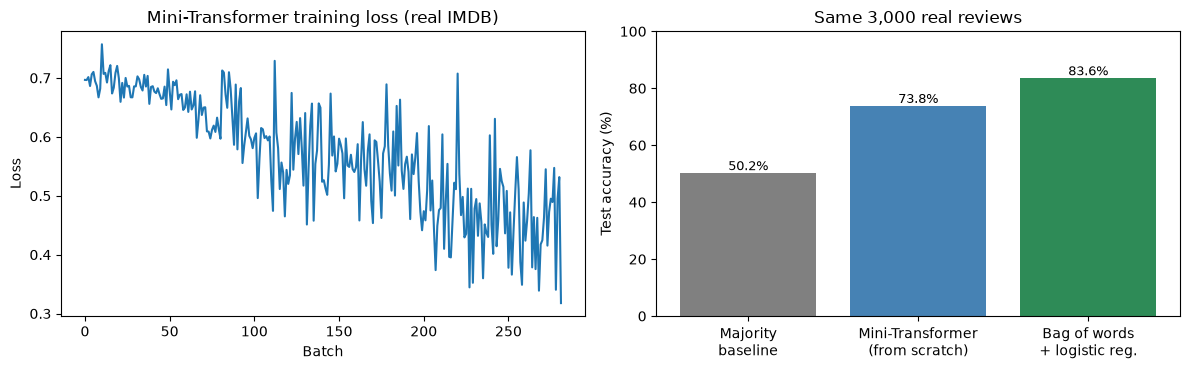

In [4]:
# WHAT: train a miniature Transformer encoder from scratch on real IMDB reviews, then compare it
#       against bag-of-words logistic regression on exactly the same reviews.
# WHY: every ingredient of BERT is here in miniature - embeddings, positions, self-attention,
#      a head - so this shows what the architecture is worth WITHOUT pretraining and at small scale.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from scipy.sparse import csr_matrix

torch.manual_seed(42)
np.random.seed(42)

PT_VOCAB, PT_SEQ, D_MODEL = 5_000, 120, 64

# ── Real data: the same IMDB reviews, re-tokenised for the PyTorch model ────
(pt_train_raw, pt_y_train), (pt_test_raw, pt_y_test) = keras.datasets.imdb.load_data(num_words=PT_VOCAB)
def pt_pad(seqs):
    return keras.preprocessing.sequence.pad_sequences(
        seqs, maxlen=PT_SEQ, padding="post", truncating="post")

rng = np.random.default_rng(0)
i_tr = rng.permutation(len(pt_train_raw))[:6000]
i_te = rng.permutation(len(pt_test_raw))[:3000]
X_tr = torch.tensor(pt_pad(pt_train_raw[i_tr]), dtype=torch.long)
y_tr = torch.tensor(pt_y_train[i_tr], dtype=torch.long)
X_te = torch.tensor(pt_pad(pt_test_raw[i_te]), dtype=torch.long)
y_te = torch.tensor(pt_y_test[i_te], dtype=torch.long)
print(f"{len(X_tr):,} training reviews, {len(X_te):,} test reviews, {PT_SEQ} tokens each")

# ── Mini Transformer ────────────────────────────────────────────────────────
# Token embedding + learned position embedding -> 2 Transformer layers -> masked mean-pool -> classify.
class MiniTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(PT_VOCAB, D_MODEL, padding_idx=0)
        self.pos_enc = nn.Embedding(PT_SEQ, D_MODEL)   # learnable positional encoding
        layer = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=4, dim_feedforward=128,
                                           dropout=0.1, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2, enable_nested_tensor=False)
        self.classifier = nn.Linear(D_MODEL, 2)
    def forward(self, x):
        pad = (x == 0)                                  # True where the review has run out
        h = self.embed(x) + self.pos_enc(torch.arange(x.size(1)))
        h = self.encoder(h, src_key_padding_mask=pad)   # never attend to padding
        # Mean-pool over the REAL tokens only, otherwise short reviews get averaged towards zero.
        h = h.masked_fill(pad.unsqueeze(-1), 0.0).sum(1) / (~pad).sum(1, keepdim=True).clamp(min=1)
        return self.classifier(h)

model_pt = MiniTransformer()
opt = optim.Adam(model_pt.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)

losses, epoch_acc = [], []
for epoch in range(3):
    model_pt.train()
    for xb, yb in loader:
        loss = loss_fn(model_pt(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    model_pt.eval()
    with torch.no_grad():
        a = (model_pt(X_te).argmax(1) == y_te).float().mean().item()
    epoch_acc.append(a)
    print(f"  epoch {epoch + 1}: test accuracy {a * 100:.1f}%")
transformer_acc = epoch_acc[-1]

# ── The baseline that has to be beaten: bag of words + logistic regression ──
def bag_of_words(seqs):
    """One row per review, one column per word id, 1 if the word occurs. No order at all."""
    rows, cols = [], []
    for i, s in enumerate(seqs):
        for t in set(s):
            if t < PT_VOCAB:
                rows.append(i); cols.append(t)
    return csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(len(seqs), PT_VOCAB))

bow_model = LogisticRegression(max_iter=1000).fit(bag_of_words(pt_train_raw[i_tr]), pt_y_train[i_tr])
bow_acc = (bow_model.predict(bag_of_words(pt_test_raw[i_te])) == pt_y_test[i_te]).mean()
majority_pt = max(pt_y_test[i_te].mean(), 1 - pt_y_test[i_te].mean())

n_params = sum(p.numel() for p in model_pt.parameters())
print(f"\nMini-Transformer from scratch ({n_params:,} params): {transformer_acc * 100:.1f}%")
print(f"Bag-of-words + logistic regression (no order at all): {bow_acc * 100:.1f}%")
print(f"Majority-class baseline:                              {majority_pt * 100:.1f}%")
print(f"\nWHAT ACTUALLY HAPPENED: the Transformer LOST to bag of words by "
      f"{(bow_acc - transformer_acc) * 100:.1f} points.")
print("That is the expected result and it is worth internalising. Self-attention is a")
print("data-hungry architecture: 6,000 reviews and 3 epochs are nowhere near enough to learn")
print("word meaning from scratch, while a linear model over word counts only has to learn one")
print("weight per word. Transformers win on this task ONLY once they arrive pretrained on")
print("billions of tokens - BERT reaches ~94% on SST-2, and notebook 05 fine-tunes exactly that.")
print("Do not quote an architecture's benchmark score as if your from-scratch copy inherited it.")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(losses)
axes[0].set_title("Mini-Transformer training loss (real IMDB)")
axes[0].set_xlabel("Batch"); axes[0].set_ylabel("Loss")
bars = ["Majority\nbaseline", "Mini-Transformer\n(from scratch)", "Bag of words\n+ logistic reg."]
vals = [majority_pt * 100, transformer_acc * 100, bow_acc * 100]
axes[1].bar(bars, vals, color=["grey", "steelblue", "seagreen"])
for i, v in enumerate(vals):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
axes[1].set_ylim(0, 100); axes[1].set_ylabel("Test accuracy (%)")
axes[1].set_title("Same 3,000 real reviews")
plt.tight_layout(); plt.show()


## 🧩 Mini-exercise

**Try it:** Change `num_heads` (2 → 4) or `d_model` in Step 2 and re-run Steps 2–3. Two things to report: does held-out accuracy move by more than a point, and does the attention spread (`max/min`) over the sample review get any sharper? Then try removing the `attention_mask` argument and re-check the "one attention row sums to …" line — you should see it drop below 1, because probability mass leaks onto padding.

---

## ✅ Summary

**What you did:** Built a classifier around **MultiHeadAttention** with a proper padding mask, trained it on **real IMDB reviews**, and read the attention weights over an actual review decoded back into English. Then trained a from-scratch mini-Transformer and put it next to bag-of-words logistic regression.

**What actually happened:**
- The attention classifier reached about **83%** on 4,000 held-out real reviews against a ~50% majority baseline — the layer clearly learned something.
- The attention weights over the sample review **rank** sensibly (sentiment words come out on top) but the **spread is tiny** — roughly 1.05–1.1× uniform. A single attention layer at this scale largely averages the sentence. Attention maps are a weak diagnostic, not an explanation.
- The from-scratch mini-Transformer scored about **74%** and **lost to bag-of-words logistic regression at about 84%**. Self-attention is data-hungry; at 6,000 reviews the linear model wins.

**In real life you'd also:** Use full transformer blocks (FFN, layer norm, residuals), start from a **pretrained** checkpoint, and use far more data — which is exactly the difference between this notebook and `05_bert_finetuning`.

**The main idea:** Self-attention lets each position attend to all positions and scales beautifully — but the scaling is the whole point. Without pretraining and volume, the architecture alone does not beat a bag of words.

**Next:** `05_bert_finetuning` and `06_gpt_text_generation` use transformer-based models that arrive already pretrained.


## 🔭 State of the field (2026)

The mathematics on this page is unchanged in 2026 — softmax(QKᵀ)V, multiple heads, a padding mask. What moved is that attention is now treated as an **input/output problem rather than an arithmetic one**. FlashAttention-3 (arXiv 2407.08608) computes *exactly* the same function you just built and is fast because it never materialises the full sequence-by-sequence score matrix in slow memory; it is exact, not approximate. At generation time the dominant cost is not attention arithmetic at all but the key/value cache, whose management has become its own subfield with a survey-level consolidation (arXiv 2607.08057). Two named techniques are worth knowing by the time you leave this unit: **paged attention** stores that cache in fixed-size blocks the way an operating system pages memory (arXiv 2309.06180), and **speculative decoding** gets more than one token per call to the expensive model with the output distribution left provably unchanged (arXiv 2211.17192).

**Why this lesson comes first.** You cannot understand why a paged KV cache or a fused kernel helps until you know which tensors exist and how large each one is — which is what building the layer by hand gives you. The honesty check in Step 3 also survives untouched: an attention map is still not an explanation, and in 2026 that argument extends to reasoning traces as well. This is the CORE the official plan examines; the memory story is the commentary that makes it deployable.


## 📚 References

1. Bahdanau, D., Cho, K. & Bengio, Y. (2015). *Neural Machine Translation by Jointly Learning to Align and Translate*. ICLR. https://arxiv.org/abs/1409.0473
2. Vaswani, A. et al. (2017). *Attention Is All You Need*. NeurIPS. https://arxiv.org/abs/1706.03762
3. Tay, Y., Dehghani, M., Bahri, D. & Metzler, D. (2022). *Efficient Transformers: A Survey*. ACM Computing Surveys. https://arxiv.org/abs/2009.06732
4. Jain, S. & Wallace, B. C. (2019). *Attention is not Explanation*. NAACL. https://arxiv.org/abs/1902.10186 — why an attention map is not evidence of why a model decided something; the honesty check in Step 3 is a small version of their argument.
5. Wiegreffe, S. & Pinter, Y. (2019). *Attention is not not Explanation*. EMNLP. https://arxiv.org/abs/1908.04626 — the reply; read both before you put an attention heatmap in a report.
6. Maas, A. L. et al. (2011). *Learning Word Vectors for Sentiment Analysis*. ACL — the paper that introduced the IMDB dataset used here. https://aclanthology.org/P11-1015/

**Data source:** IMDB Large Movie Review Dataset (Maas et al., 2011), 50,000 real reviews, shipped with Keras and cached locally. Used unmodified apart from vocabulary truncation, padding and subsampling, all stated in the code.

**Attention as a memory problem (2022–2026)** — the mapped §9 additions for this unit

7. Dao et al. (2022). *FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness*. arXiv. https://arxiv.org/abs/2205.14135 — the paper that made attention an input/output problem rather than a FLOP-counting one. It is **exact**, not approximate: same function, fewer trips to slow memory.
8. Leviathan et al. (2022). *Fast Inference from Transformers via Speculative Decoding*. arXiv. https://arxiv.org/abs/2211.17192 — get more than one token per call to the big model, with the output distribution provably unchanged.
9. Kwon et al. (2023). *Efficient Memory Management for Large Language Model Serving with PagedAttention*. arXiv. https://arxiv.org/abs/2309.06180 — vLLM's paged key/value cache: operating-system paging applied to the tensors this notebook never has to store.
10. Shah et al. (2024). *FlashAttention-3: Fast and Accurate Attention with Asynchrony and Low-precision*. arXiv. https://arxiv.org/abs/2407.08608 — the current kernel baseline on modern GPUs (asynchrony, FP8); still computing exactly the softmax(QKᵀ)V you built above.
11. Jiang et al. (2026). *Towards Efficient Large Language Model Serving: A Survey on System-Aware KV Cache Optimization*. arXiv. https://arxiv.org/abs/2607.08057 — the 2026 consolidation: key/value cache management became its own subfield, organised along temporal, spatial and structural axes.
